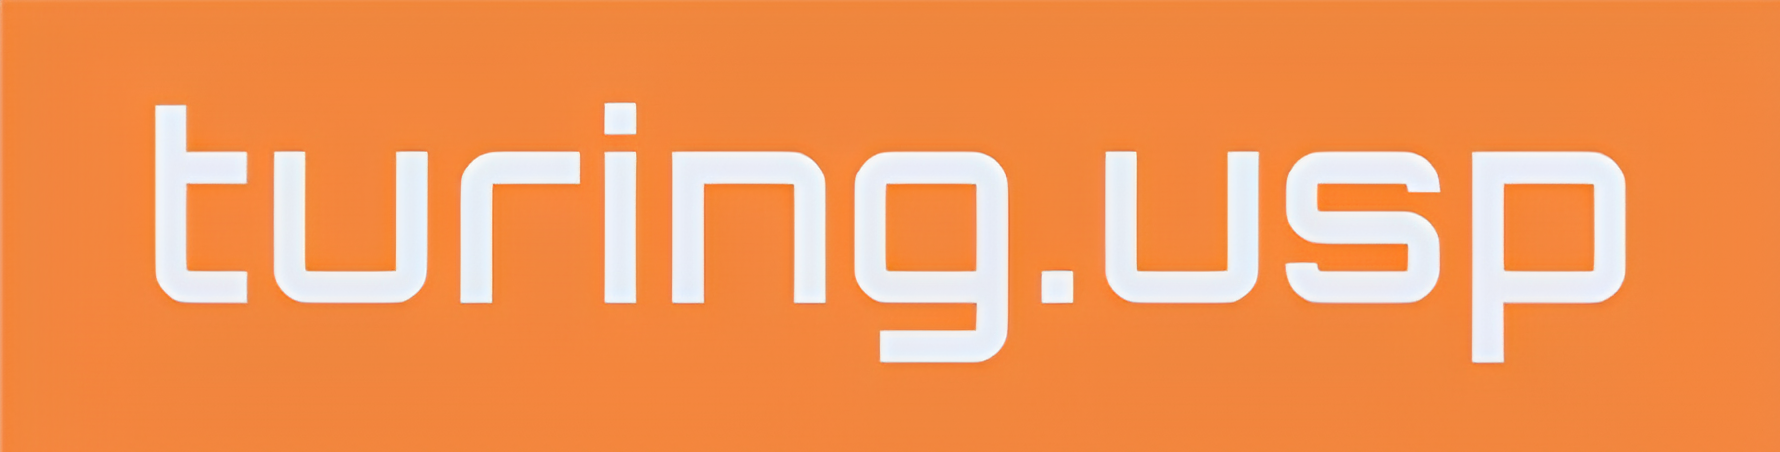


# Turing Usp - Reinforcement Learning
## VizDoom - Treinando um Agente via Colab

Não clique duas vezes na caixa de texto acima, ela pode travar seu pc (a importação de imagem no Colab é meio complicada).

Esse .ipynb é feito para **rodar diretamente no Colab**. Algumas funções podem ter leve alterações se você tentar rodar nativamente ele, ou na extensão do Colab para o VS Code (em especial, as voltadas para o upload, já que esse arquivo espera uma pasta /content/ do Colab para operar). Se você acessou **pelo git**, esteja atento a isso. Note também que esse Colab roda em grande parte **por cima de nosso framework**, de tal forma que convém você já ter ele instalado em seu PC. Feito isso, precisamos de algumas coisas:

1. Que você comprima sua pasta Framework, para conseguirmos rodar nosso agente!
2. Que você tenha algum agente já treinado, pois esse Colab se propõe a treinar ele
3. Que você tenha o mapa de interesse. Para acessa-lo, crie um venv e procure por 'scenarios' nas suas pastas ocultas (no Linux, Ctlr + H)

### Fazendo algumas instalações para o VizDoom funcionar no Colab:

Abaixo, fazemos o Download de dois componentes muito importantes:

1. Dependências de Sistema - Estão no apt-get, consistem em ferramentas que "traduzam" o VizDoom de C++ para Python
2. Bibliotecas: Contém todas as bibliotecas que usaremos durante o treinamento

In [1]:
!apt-get install -y cmake libboost-all-dev
!pip install vizdoom
!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install opencv-python
!pip install matplotlib


### Subindo nossos arquivos

Então, vamos subir nossos arquivos como mencionado anteriormente:
(Subir zip's demora muito, não estranhe)

In [4]:
from google.colab import files
import zipfile, os

print("Faça o upload dos arquivos de cenários (.cfg e .wad):")
uploaded_cfg = files.upload()

scenario_path = list(uploaded_cfg.keys())[0]

print("\n Faça o upload do arquivo ZIP do seu agente:")
uploaded_agent = files.upload()

print("\n Faça o upload do seu arquivo .yaml:")
uploaded_yaml = files.upload()

print("\n E, por fim, faça o upload do seu framework zipado:")
framework = files.upload()

# Extrair o zip do agente e do framework
agent_zip = list(uploaded_agent.keys())[0]
if agent_zip.endswith(".zip"):
    with zipfile.ZipFile(agent_zip, 'r') as zip_ref:
        zip_ref.extractall("agent")

framework_zip = list(framework.keys())[0]
if framework_zip.endswith(".zip"):
    with zipfile.ZipFile(framework_zip, 'r') as zip_ref:
        zip_ref.extractall("framework")



### Configurando o Stable-Baselines

Em seguida, podemoos começar a configurar o modelo do stable-baselines. Note que essa célula é uma adaptação bem direta de env.py e client.py, adaptada para rodar no Colab.

In [6]:
from vizdoom import *
from gymnasium import Env
from gymnasium.spaces import Discrete, Box
import numpy as np
import cv2
import yaml

# Importando a lógica do seu framework. Atente-se ao nome da pasta!
from framework.framework.rewards import RewardShaper
from framework.framework.client import load_agent_cfg

class VizDoomGym(Env):
    def __init__(self, scenario_path, agent_cfg, render=False):
        super().__init__()
        self.game = DoomGame()
        self.game.load_config(scenario_path)
        self.game.set_window_visible(render)

        # Peculiaridade: Habilitar variáveis para o RewardShaper
        self.game.add_available_game_variable(GameVariable.HEALTH)
        self.game.add_available_game_variable(GameVariable.ARMOR)
        self.game.add_available_game_variable(GameVariable.AMMO2)
        self.game.add_available_game_variable(GameVariable.FRAGCOUNT)
        self.game.add_available_game_variable(GameVariable.DEATHCOUNT)
        self.game.add_available_game_variable(GameVariable.HITCOUNT)
        self.game.add_available_game_variable(GameVariable.HITS_TAKEN)

        self.game.init()

        # Resolução vinda do config do framework
        self.NET_W, self.NET_H = 160, 120
        self.observation_space = Box(low=0, high=255, shape=(self.NET_H, self.NET_W, 1), dtype=np.uint8)

        # Peculiaridade: As 8 ações discretas do framework
        self._actions = [
            [0,0,0,0,0,0], [0,0,1,0,0,0], [0,0,0,1,0,0], [0,0,0,0,1,0],
            [0,0,1,0,0,1], [1,0,0,0,0,0], [0,1,0,0,0,0], [0,0,0,0,0,1]
        ]
        self.action_space = Discrete(8)

        # Inicializa o Shaper com as configs do YAML
        self.shaper = RewardShaper(agent_cfg.reward.shaping)

    def step(self, action):
        # O framework usa frame_skip=4 por padrão
        engine_reward = self.game.make_action(self._actions[action], 4)

        # RECOMPENSA CUSTOMIZADA: Delta de variáveis
        reward = self.shaper.compute(self.game, engine_reward)

        terminated = self.game.is_episode_finished()

        if not terminated:
            state = self.game.get_state().screen_buffer
            state = self.grayscale(state)
            info = {"frags": self.game.get_game_variable(GameVariable.FRAGCOUNT)}
        else:
            state = np.zeros(self.observation_space.shape)
            info = {}

        return state, reward, terminated, False, info

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.game.new_episode()
        self.shaper.reset(self.game) # Reseta memória do shaper
        state = self.game.get_state().screen_buffer
        return self.grayscale(state), {}

    def grayscale(self, obs):
        if obs is None: return np.zeros((self.NET_H, self.NET_W, 1), dtype=np.uint8)
        gray = cv2.cvtColor(np.moveaxis(obs, 0, -1), cv2.COLOR_BGR2GRAY)
        resize = cv2.resize(gray, (self.NET_W, self.NET_H), interpolation=cv2.INTER_AREA)
        return np.reshape(resize, (self.NET_H, self.NET_W, 1))

    def render(self): pass
    def close(self): self.game.close()

In [8]:
from stable_baselines3 import PPO
import os
from google.colab import files
from framework.framework.client import load_agent_cfg
from framework.framework.policies import _coerce_learn_kwargs

yaml_filename = list(uploaded_yaml.keys())[0]

# Transforma o arquivo em um objeto AgentConfig
agent_cfg = load_agent_cfg(yaml_filename)

# Limpa os argumentos do YAML para garantir que são números e não strings
learn_kwargs = _coerce_learn_kwargs(agent_cfg.policy.learn_kwargs)

CHECKPOINT_DIR = './train/train_custom'
LOG_DIR = './logs/log_custom'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

env = VizDoomGym(scenario_path, agent_cfg, render=False)

policy_kwargs = {
    "net_arch": agent_cfg.policy.policy_kwargs.get("net_arch", {
        "pi": [256, 512, 512],
        "vf": [512, 512, 256]
    })
}

# Define o Modelo
model = PPO(
    "CnnPolicy",
    env,
    policy_kwargs=policy_kwargs,
    tensorboard_log=LOG_DIR,
    verbose=1,
    # Usamos os valores já convertidos para float/int
    learning_rate=learn_kwargs.get("learning_rate_max", 0.0001),
    n_steps=learn_kwargs.get("n_steps", 256),
    batch_size=learn_kwargs.get("batch_size", 3072),
    ent_coef=learn_kwargs.get("ent_coef", 0.05)
)

### Treinando o Modelo

Por fim, podemos finalmente treinar nosso modelo configurado!
Para isto, basta rodar a célula abaixo:

In [ ]:

model.learn(total_timesteps=agent_cfg.train_steps)